In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/TechMasterDataset/spam.csv', encoding='latin-1')

In [20]:
df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it s been 3 week s n...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile 11 months or more u r entitled...


In [28]:
#final check on data
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nLabels:")
print(df["label"].value_counts())

print("\nEmpty cleaned messages:",
      df["clean_message"].str.strip().eq("").sum())

Shape: (5167, 3)

Missing values:
label            0
message          0
clean_message    0
dtype: int64

Duplicates: 0

Labels:
label
ham     4514
spam     653
Name: count, dtype: int64

Empty cleaned messages: 0


**2.Train and Test Split**

In [29]:
from sklearn.model_selection import train_test_split

X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training samples: 4133
Testing samples: 1034

Training distribution:
label
ham     87.369949
spam    12.630051
Name: proportion, dtype: float64

Testing distribution:
label
ham     87.330754
spam    12.669246
Name: proportion, dtype: float64


**Imports**

In [33]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

**Load The Dataset**

In [34]:
df = pd.read_csv(
    "/content/drive/MyDrive/TechMasterDataset/cleaned_spam.csv"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5167, 3)


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [35]:
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nClass distribution:")
print(df["label"].value_counts())

label            0
message          0
clean_message    0
dtype: int64

Duplicates: 0

Class distribution:
label
ham     4514
spam     653
Name: count, dtype: int64


In [36]:
X = df["clean_message"].astype(str)

y = df["label"].map({
    "ham": 0,
    "spam": 1
})

**Train & Test Split**

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4133
Testing samples: 1034


**## 1. Feature Extraction — CountVectorizer**

In [38]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("Training feature shape:", X_train_count.shape)
print("Testing feature shape:", X_test_count.shape)
print("Vocabulary size:", len(count_vectorizer.vocabulary_))

Training feature shape: (4133, 7632)
Testing feature shape: (1034, 7632)
Vocabulary size: 7632


**## 2. Logistic Regression with CountVectorizer**

In [39]:
from sklearn.linear_model import LogisticRegression

lr_count = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_count.fit(X_train_count, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [40]:
#prediction
y_pred_count = lr_count.predict(X_test_count)

print(y_pred_count[:20])

[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [41]:
#Eval
print("Logistic Regression + CountVectorizer")

print(
    classification_report(
        y_test,
        y_pred_count,
        target_names=["ham", "spam"]
    )
)

Logistic Regression + CountVectorizer
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.98      0.87      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [42]:
accuracy_count = accuracy_score(y_test, y_pred_count)

print("Accuracy:", accuracy_count)

Accuracy: 0.9816247582205029


In [43]:
# Overfitting / Underfitting Check

train_accuracy = lr_count.score(X_train_count, y_train)
test_accuracy = lr_count.score(X_test_count, y_test)

gap = train_accuracy - test_accuracy

print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Train-Test Gap:", round(gap, 4))

if train_accuracy < 0.85:
    print("Status: Underfitting")
elif gap > 0.05:
    print("Status: Possible Overfitting")
else:
    print("Status: Good Fit")

Train Accuracy: 0.9976
Test Accuracy: 0.9816
Train-Test Gap: 0.016
Status: Good Fit


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

Training feature shape: (4133, 7632)
Testing feature shape: (1034, 7632)
Vocabulary size: 7632


**## 3. Logistic Regression with TF-IDF**

In [45]:
lr_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [46]:
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

print(y_pred_tfidf[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [47]:
print("Logistic Regression + TF-IDF")

print(
    classification_report(
        y_test,
        y_pred_tfidf,
        target_names=["ham", "spam"]
    )
)

accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("Accuracy:", accuracy_tfidf)

Logistic Regression + TF-IDF
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       0.99      0.78      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034

Accuracy: 0.9709864603481625


In [48]:
train_accuracy_tfidf = lr_tfidf.score(X_train_tfidf, y_train)
test_accuracy_tfidf = lr_tfidf.score(X_test_tfidf, y_test)

gap_tfidf = train_accuracy_tfidf - test_accuracy_tfidf

print("Train Accuracy:", round(train_accuracy_tfidf, 4))
print("Test Accuracy:", round(test_accuracy_tfidf, 4))
print("Train-Test Gap:", round(gap_tfidf, 4))

if train_accuracy_tfidf < 0.85:
    print("Status: Underfitting")
elif gap_tfidf > 0.05:
    print("Status: Possible Overfitting")
else:
    print("Status: Good Fit")

Train Accuracy: 0.9727
Test Accuracy: 0.971
Train-Test Gap: 0.0017
Status: Good Fit


[[901   2]
 [ 17 114]]


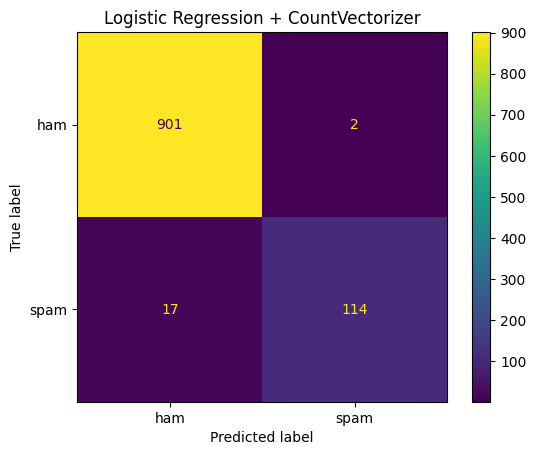

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_count)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.title("Logistic Regression + CountVectorizer")
plt.show()

In [50]:
import joblib

joblib.dump(lr_count, "logistic_regression_count.pkl")
joblib.dump(count_vectorizer, "count_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
